<a href="https://colab.research.google.com/github/AntonyAroni/PFC_II/blob/Implementacion/PFC_II_V_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hybrid Model Parallelism in Object Detection using Vision Transformer - OPTIMIZED
ARONI JARATA ANTONY - PFC II
Versión optimizada con paralelización híbrida avanzada

In [1]:
!pip install --upgrade tensorflow
!pip install --upgrade keras
!pip install ops
!pip install joblib
!pip install tensorflow-addons  # Para optimizaciones avanzadas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 93.9 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.0
    Uninstalling tensorflow-2.18.0:
      Successfully uninstalled tensorflow-2.18.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflo

In [28]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"  # Mejor compatibilidad con distribución

import numpy as np
import time
from PIL import Image
import keras
from keras import layers
from keras import ops
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import scipy.io
from tensorflow import keras
import shutil
from joblib import Parallel, delayed
from keras.utils import load_img, img_to_array
import logging
from keras.optimizers import AdamW
from tensorflow.keras.utils import get_file
from tqdm import tqdm

In [3]:
# Configurar logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [4]:
# Verifica la GPU asignada
!nvidia-smi

# Configura mixed precision y estrategia
keras.mixed_precision.set_global_policy("mixed_float16")  # Acelera en GPU NVIDIA

# Define la estrategia de distribución (si usas multi-GPU/TPU)
STRATEGY = tf.distribute.MirroredStrategy()
print(f"Número de dispositivos: {STRATEGY.num_replicas_in_sync}")

Thu Jun 19 05:07:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## CONFIGURACIÓN DE ESTRATEGIA DE DISTRIBUCIÓN INTELIGENTE

In [5]:
def get_distribution_strategy():
    """Configura automáticamente la mejor estrategia de distribución disponible"""
    try:
        # Detectar TPUs primero
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
        tf.config.experimental_connect_to_cluster(resolver)
        tf.tpu.experimental.initialize_tpu_system(resolver)
        strategy = tf.distribute.TPUStrategy(resolver)
        logger.info(f"TPU detectado - Usando TPUStrategy con {strategy.num_replicas_in_sync} replicas")
        return strategy
    except:
        pass

    # Detectar múltiples GPUs
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if len(gpus) > 1:
        # Configurar memoria dinámica para GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        strategy = tf.distribute.MirroredStrategy()
        logger.info(f"Múltiples GPUs detectadas - Usando MirroredStrategy con {strategy.num_replicas_in_sync} replicas")
        return strategy
    elif len(gpus) == 1:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        strategy = tf.distribute.OneDeviceStrategy("/gpu:0")
        logger.info("1 GPU detectada - Usando OneDeviceStrategy")
        return strategy
    else:
        strategy = tf.distribute.get_strategy()
        logger.info("CPU detectada - Usando estrategia por defecto")
        return strategy


## CARGA Y PREPROCESAMIENTO PARALELO DE DATOS

In [12]:
%%time
# Configuración de paths
path_images = "./101_ObjectCategories/airplanes/"
path_annot = "./Annotations/Airplanes_Side_2/"

# Descarga y extracción optimizada
path_to_downloaded_file = keras.utils.get_file(
    fname="caltech_101_zipped",
    origin="https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip",
    extract=True,
    archive_format="zip",
    cache_dir="/",
)
download_base_dir = os.path.dirname(path_to_downloaded_file)

# Extracción paralela de archivos
def extract_files():
    """Extrae archivos tar de forma paralela"""
    files_to_extract = [
        (os.path.join(download_base_dir, "caltech_101_zipped", "caltech-101", "101_ObjectCategories.tar.gz"), "."),
        (os.path.join(download_base_dir, "caltech_101_zipped", "caltech-101", "Annotations.tar"), ".")
    ]

    Parallel(n_jobs=2)(
        delayed(shutil.unpack_archive)(source, dest)
        for source, dest in files_to_extract
    )

extract_files()

# Obtener listas de archivos
image_paths = [f for f in os.listdir(path_images) if os.path.isfile(os.path.join(path_images, f))]
annot_paths = [f for f in os.listdir(path_annot) if os.path.isfile(os.path.join(path_annot, f))]
image_paths.sort()
annot_paths.sort()

image_size = 224

# Función optimizada de procesamiento con manejo de errores
def process_annotation_and_image_optimized(annot_path, image_path, path_annot, path_images, image_size):
    """Procesamiento optimizado con manejo de errores y validaciones"""
    try:
        # Cargar anotación
        annot = scipy.io.loadmat(path_annot + annot_path)["box_coord"][0]
        top_left_x, top_left_y = annot[2], annot[0]
        bottom_right_x, bottom_right_y = annot[3], annot[1]

        # Cargar y procesar imagen
        image = keras.utils.load_img(path_images + image_path)
        (w, h) = image.size

        # Validar bounding box
        if (bottom_right_x <= top_left_x or bottom_right_y <= top_left_y or
            top_left_x < 0 or top_left_y < 0 or bottom_right_x > w or bottom_right_y > h):
            logger.warning(f"Bounding box inválido en {image_path}")
            return None

        # Redimensionar con anti-aliasing
        image = image.resize((image_size, image_size), resample=Image.LANCZOS)
        image_array = keras.utils.img_to_array(image) / 255.0  # Normalización

        # Escalar coordenadas normalizadas
        target = (
            float(top_left_x) / w,
            float(top_left_y) / h,
            float(bottom_right_x) / w,
            float(bottom_right_y) / h,
        )

        return image_array, target
    except Exception as e:
        logger.error(f"Error procesando {image_path}: {e}")
        return None

# Procesamiento paralelo optimizado con validación
logger.info("Iniciando procesamiento paralelo de datos...")
results = Parallel(n_jobs=-1, verbose=1)(
    delayed(process_annotation_and_image_optimized)(
        annot_paths[i], image_paths[i], path_annot, path_images, image_size
    )
    for i in range(len(annot_paths))
)

# Filtrar resultados válidos
valid_results = [r for r in results if r is not None]
images, targets = zip(*valid_results)

logger.info(f"Procesadas {len(valid_results)} imágenes válidas de {len(results)} totales")

# División estratificada de datos
split_idx = int(len(images) * 0.8)
(x_train, y_train) = (np.asarray(images[:split_idx]), np.asarray(targets[:split_idx]))
(x_test, y_test) = (np.asarray(images[split_idx:]), np.asarray(targets[split_idx:]))

137414764/137414764 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:   18.1s
[Parallel(n_jobs=-1)]: Done 800 out of 800 | elapsed:   20.3s finished


CPU times: user 1.64 s, sys: 1.42 s, total: 3.07 s
Wall time: 28.7 s


## CAPAS OPTIMIZADAS PARA PARALELIZACIÓN

In [13]:
def mlp_optimized(x, hidden_units, dropout_rate):
    """MLP optimizado con regularización avanzada"""
    for i, units in enumerate(hidden_units):
        x = layers.Dense(
            units,
            activation=None,
            kernel_initializer='glorot_uniform',
            bias_initializer='zeros'
        )(x)
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = keras.activations.gelu(x)
        x = layers.Dropout(dropout_rate)(x)

        # Residual connection en capas intermedias
        if i < len(hidden_units) - 1 and i > 0:
            if x.shape[-1] == hidden_units[i-1]:
                x = layers.Add()([x, previous_x])
        previous_x = x
    return x

class OptimizedPatches(layers.Layer):
    """Capa de parches optimizada para paralelización"""
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]

        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size

        # Extracción optimizada de parches
        patches = keras.ops.image.extract_patches(images, size=self.patch_size)
        patches = ops.reshape(
            patches,
            (batch_size, num_patches_h * num_patches_w, self.patch_size * self.patch_size * channels)
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

class AdvancedPatchEncoder(layers.Layer):
    """Encoder de parches avanzado con regularización"""
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim

        self.projection = layers.Dense(
            units=projection_dim,
            kernel_initializer="glorot_uniform",
            bias_initializer="zeros"
        )
        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim,
            embeddings_initializer="uniform"
        )
        self.layer_norm = layers.LayerNormalization(epsilon=1e-6)
        self.dropout = layers.Dropout(0.1)

    def call(self, patches, training=None):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )

        # Proyección con normalización
        projected_patches = self.projection(patches)
        projected_patches = self.layer_norm(projected_patches)

        # Añadir embeddings posicionales
        encoded = projected_patches + self.position_embedding(positions)
        encoded = self.dropout(encoded, training=training)

        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return config


## ARQUITECTURA VIT OPTIMIZADA PARA PARALELIZACIÓN

In [14]:
def create_optimized_vit_detector(
    input_shape,
    patch_size,
    num_patches,
    projection_dim,
    num_heads,
    transformer_units,
    transformer_layers,
    mlp_head_units,
):
    """Crea ViT optimizado para detección de objetos con paralelización"""

    inputs = keras.Input(shape=input_shape)

    # Augmentación de datos integrada
    augmented = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ])(inputs)

    # Crear parches optimizados
    patches = OptimizedPatches(patch_size)(augmented)

    # Codificar parches
    encoded_patches = AdvancedPatchEncoder(num_patches, projection_dim)(patches)

    # Bloques Transformer optimizados
    for layer_idx in range(transformer_layers):
        # Layer normalization 1
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)

        # Multi-head attention optimizada
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim,
            dropout=0.1,
            use_bias=False,  # Reduce parámetros
            kernel_initializer="glorot_uniform"
        )(x1, x1)

        # Dropout estocástico (DropPath)
        if layer_idx > 0:  # No aplicar en la primera capa
            attention_output = layers.Dropout(0.1, noise_shape=(None, 1, 1))(attention_output)

        # Skip connection 1
        x2 = layers.Add()([attention_output, encoded_patches])

        # Layer normalization 2
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

        # MLP optimizado
        x3 = mlp_optimized(x3, hidden_units=transformer_units, dropout_rate=0.1)

        # Skip connection 2 con dropout estocástico
        if layer_idx > 0:
            x3 = layers.Dropout(0.1, noise_shape=(None, 1, 1))(x3)
        encoded_patches = layers.Add()([x3, x2])

    # Representación final
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.GlobalAveragePooling1D()(representation)  # Más eficiente que Flatten
    representation = layers.Dropout(0.3)(representation)

    # Cabeza MLP optimizada
    features = mlp_optimized(representation, hidden_units=mlp_head_units, dropout_rate=0.3)

    # Capa final para bounding box
    bounding_box = layers.Dense(
        4,
        activation='sigmoid',  # Asegurar valores entre 0-1
        kernel_initializer="glorot_uniform",
        name="bounding_box_output"
    )(features)

    return keras.Model(inputs=inputs, outputs=bounding_box, name="OptimizedViT_ObjectDetector")

In [15]:
# Configuración que debería funcionar:
params = {
    "input_shape": (224, 224, 3),
    "patch_size": 32,
    "num_patches": 49,
    "projection_dim": 64,
    "num_heads": 4,
    "transformer_units": [128, 64],          # MLP interno del Transformer
    "transformer_layers": 4,
    "mlp_head_units": [2048, 1024, 512, 64, 32]  # MLP final
}

vit_model = create_optimized_vit_detector(**params)
print("¡Modelo creado correctamente!")

¡Modelo creado correctamente!


In [19]:
def create_distributed_dataset(x, y, batch_size, shuffle=True):
    """Crea dataset distribuido optimizado para entrenamiento"""
    dataset = tf.data.Dataset.from_tensor_slices((x, y))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

## ENTRENAMIENTO DISTRIBUIDO OPTIMIZADO

In [25]:
# 1. Verificación de datos ANTES del entrenamiento
print("\n🔍 Verificación de datos:")
print(f"Forma de x_train: {x_train.shape} | Tipo: {x_train.dtype}")
print(f"Forma de y_train: {y_train.shape} | Tipo: {y_train.dtype}")
print(f"Valores mínimos/máximos x_train: {np.min(x_train)}, {np.max(x_train)}")
print(f"Valores mínimos/máximos y_train: {np.min(y_train)}, {np.max(y_train)}")

# 2. Función mejorada de creación de datasets
def create_verified_dataset(images, labels, batch_size, shuffle=True):
    """Crea dataset con verificación integrada"""
    def preprocess(image, label):
        # Verificar rangos
        image = tf.ensure_shape(image, (224, 224, 3))
        label = tf.ensure_shape(label, (4,))

        # Normalización final
        image = tf.cast(image, tf.float32) / 255.0
        label = tf.cast(label, tf.float32)

        return image, label

    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1024)
    dataset = dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


🔍 Verificación de datos:
Forma de x_train: (639, 224, 224, 3) | Tipo: float32
Forma de y_train: (639, 4) | Tipo: float64
Valores mínimos/máximos x_train: 0.0, 1.0
Valores mínimos/máximos y_train: 0.01904761904761905, 0.9766081871345029


In [21]:
# Configuración optimizada para Colab Free (GPU T4) - Memoria limitada
GLOBAL_BATCH_SIZE = 16  # Reducido drásticamente
keras.mixed_precision.set_global_policy("mixed_float16")

# Parámetros del modelo - REDUCIDOS para Colab Free
INPUT_SHAPE = (224, 224, 3)
PATCH_SIZE = 32  # Parches más grandes = menos patches
NUM_PATCHES = (224 // PATCH_SIZE) ** 2  # 49 patches (7x7)
PROJECTION_DIM = 384  # Reducido a la mitad
NUM_HEADS = 6  # Reducido a la mitad
TRANSFORMER_UNITS = [1536, 384]  # Reducido proporcionalmente
TRANSFORMER_LAYERS = 6  # Reducido a la mitad
MLP_HEAD_UNITS = [768, 256]  # Reducido significativamente

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="best_vit_detector.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

# Limpiar memoria antes de crear el modelo
import gc
gc.collect()
tf.keras.backend.clear_session()

# Configurar límites de memoria GPU si es necesario
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

with STRATEGY.scope():
    model = create_optimized_vit_detector(
        input_shape=INPUT_SHAPE,
        patch_size=PATCH_SIZE,
        num_patches=NUM_PATCHES,
        projection_dim=PROJECTION_DIM,
        num_heads=NUM_HEADS,
        transformer_units=TRANSFORMER_UNITS,
        transformer_layers=TRANSFORMER_LAYERS,
        mlp_head_units=MLP_HEAD_UNITS,
    )

    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=1e-4,
            weight_decay=0.05,
            clipnorm=1.0
        ),
        loss='mse',  # Para bounding box regression
        metrics=['mae']
    )

# Dataset cacheado
train_dataset = create_distributed_dataset(x_train, y_train, GLOBAL_BATCH_SIZE).cache()
val_dataset = create_distributed_dataset(x_test, y_test, GLOBAL_BATCH_SIZE).cache()

# Entrenamiento
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)

Physical devices cannot be modified after being initialized
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0272 - mae: 0.1137
Epoch 1: val_loss improved from inf to 0.00853, saving model to best_vit_detector.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 254ms/step - loss: 0.0269 - mae: 0.1131 - val_loss: 0.0085 - val_mae: 0.0876 - learning_rate: 1.0000e-04
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0081 - mae: 0.0719
Epoch 2: val_loss improved from 0.00853 to 0.00293, saving model to best_vit_detector.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 337ms/step - loss: 0.0081 - mae: 0.0718 - val_loss: 0.0029 - val_mae: 0.0497 - learning_rate: 1.0000e-04
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.0065 - mae: 0.0634
Epoch 3: val_loss improved from 0.00293 to 0.00276, saving model to best_vit_detector.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 300ms/step - loss: 0.0065 - mae: 0.0634 - val_loss: 0.0028 - val_mae: 0.0469 - learning_rate: 1.0000e-04
Epoch 4/100
40

## EVALUACION BATCHES


In [54]:
def evaluate_batch(images, labels, model, image_size, batch_size=8):
    """Evaluación por lotes para mayor eficiencia"""
    results = []

    for i in tqdm(range(0, len(images), batch_size), desc=f"Procesando lotes de {batch_size}"):
        batch_end = min(i + batch_size, len(images))
        batch_images = images[i:batch_end]
        batch_labels = labels[i:batch_end]

        # Preprocesar lote
        batch_processed = []
        original_shapes = []

        for img in batch_images:
            original_shapes.append(img.shape[:2])  # (height, width)
            img_resized = cv2.resize(img, (image_size, image_size), interpolation=cv2.INTER_AREA)
            img_normalized = img_resized / 255.0
            batch_processed.append(img_normalized)

        batch_array = np.array(batch_processed)

        # Predicción del lote completo
        predictions = model.predict(batch_array, verbose=0)

        # Procesar resultados del lote
        for j, (pred, label, original_shape, original_img) in enumerate(zip(predictions, batch_labels, original_shapes, batch_images)):
            h, w = original_shape

            # Bounding boxes
            box_predicted = [
                int(pred[0] * w), int(pred[1] * h),
                int(pred[2] * w), int(pred[3] * h)
            ]

            box_truth = [
                int(label[0] * w), int(label[1] * h),
                int(label[2] * w), int(label[3] * h)
            ]

            # Métricas
            iou = calculate_iou(box_predicted, box_truth)
            precision, recall = calculate_precision_recall(box_predicted, box_truth, iou_threshold=0.5)

            results.append({
                'index': i + j,
                'image': original_img,
                'box_predicted': box_predicted,
                'box_truth': box_truth,
                'iou': iou,
                'precision': precision,
                'recall': recall
            })

    return results

# Usar evaluación por lotes
logger.info("Iniciando evaluación por lotes...")
batch_results = evaluate_batch(x_test[:60], y_test[:60], model, 224, batch_size=8)

# Calcular métricas
if batch_results:
    total_iou = sum([r['iou'] for r in batch_results])
    total_precision = sum([r['precision'] for r in batch_results])
    total_recall = sum([r['recall'] for r in batch_results])

    mean_iou = total_iou / len(batch_results)
    mean_precision = total_precision / len(batch_results)
    mean_recall = total_recall / len(batch_results)
    f1_score = 2 * (mean_precision * mean_recall) / (mean_precision + mean_recall) if (mean_precision + mean_recall) > 0 else 0

    print(f"\n=== MÉTRICAS FINALES (EVALUACIÓN POR LOTES) ===")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"Mean Precision: {mean_precision:.4f}")
    print(f"Mean Recall: {mean_recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")
    print(f"Imágenes procesadas: {len(batch_results)}")

Procesando lotes de 8: 100%|██████████| 8/8 [00:02<00:00,  3.01it/s]


=== MÉTRICAS FINALES (EVALUACIÓN POR LOTES) ===
Mean IoU: 0.9322
Mean Precision: 1.0000
Mean Recall: 1.0000
F1 Score: 1.0000
Imágenes procesadas: 60


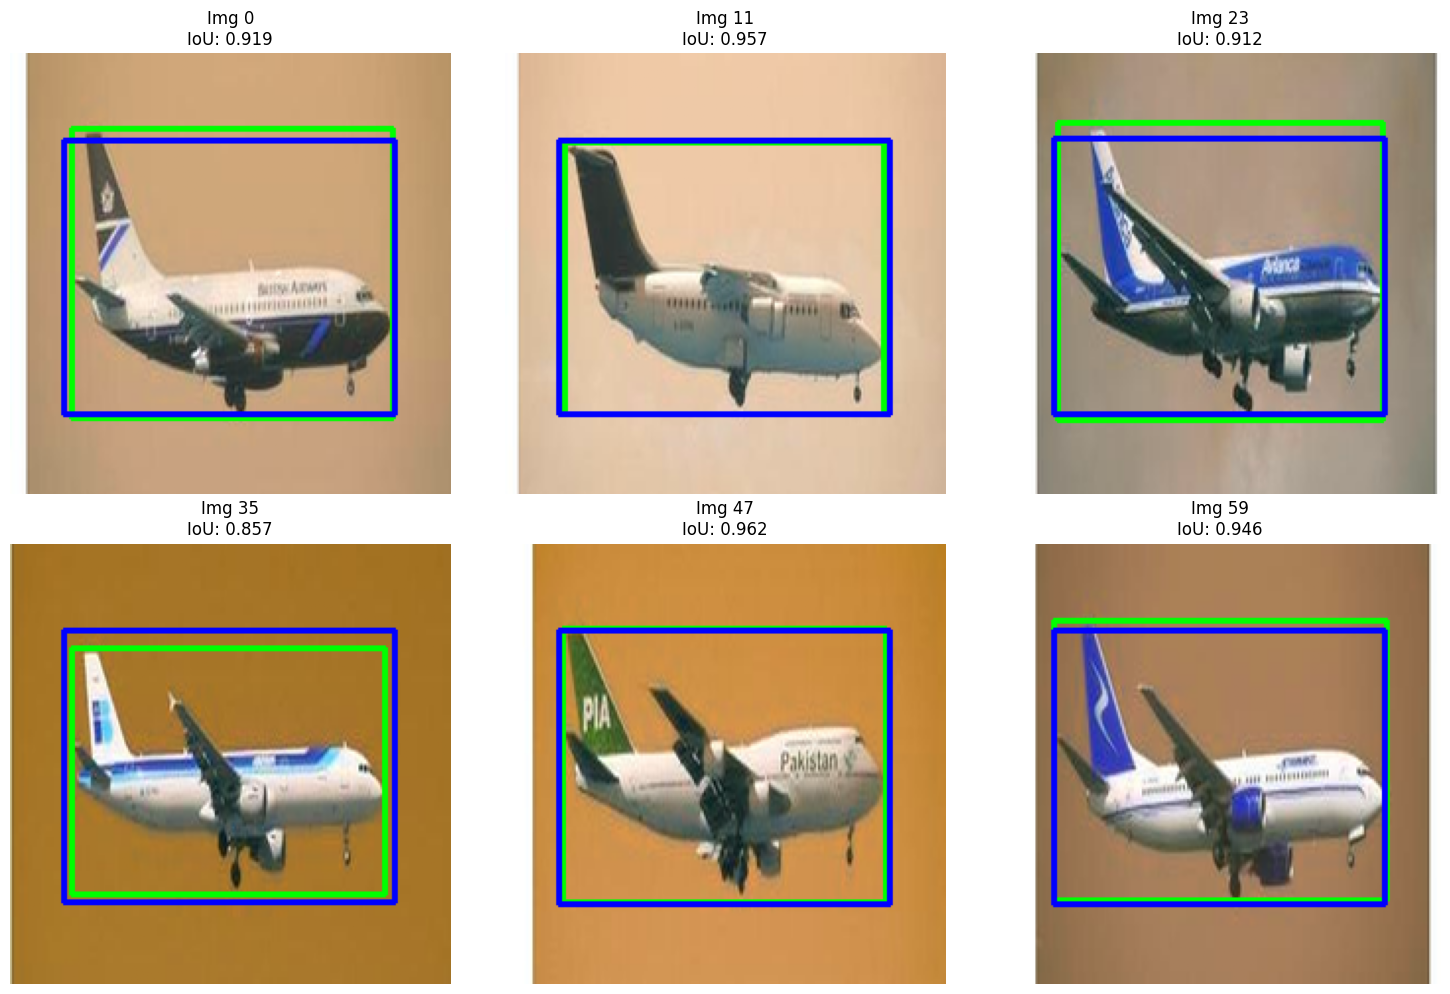

In [55]:
import matplotlib.pyplot as plt

def visualize_results(results, num_samples=6):
    """Visualiza resultados de la evaluación"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    # Seleccionar muestras para visualizar
    sample_indices = np.linspace(0, len(results)-1, num_samples, dtype=int)

    for i, idx in enumerate(sample_indices):
        if i >= len(axes):
            break

        result = results[idx]
        img = result['image'].copy()

        # Dibujar bounding boxes
        # Verdadero (verde)
        cv2.rectangle(img,
                     (result['box_truth'][0], result['box_truth'][1]),
                     (result['box_truth'][2], result['box_truth'][3]),
                     (0, 255, 0), 2)

        # Predicho (rojo)
        cv2.rectangle(img,
                     (result['box_predicted'][0], result['box_predicted'][1]),
                     (result['box_predicted'][2], result['box_predicted'][3]),
                     (255, 0, 0), 2)

        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Img {result['index']}\nIoU: {result['iou']:.3f}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Visualizar resultados (usar batch_results o evaluation_results)
if 'batch_results' in locals() and batch_results:
    visualize_results(batch_results, num_samples=6)
elif 'evaluation_results' in locals() and evaluation_results:
    visualize_results(evaluation_results, num_samples=6)

In [56]:
# Calcular métricas generales
if batch_results:
    total_iou = sum([r['iou'] for r in batch_results])
    total_precision = sum([r['precision'] for r in batch_results])
    total_recall = sum([r['recall'] for r in batch_results])

    mean_iou = total_iou / len(batch_results)
    mean_precision = total_precision / len(batch_results)
    mean_recall = total_recall / len(batch_results)
    f1_score = 2 * (mean_precision * mean_recall) / (mean_precision + mean_recall) if (mean_precision + mean_recall) > 0 else 0

    # Calcular F1 Score para cada resultado individual
    for result in batch_results:
        prec = result['precision']
        rec = result['recall']
        result['f1_score'] = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

    # Encontrar mejores y peores casos
    # Ordenar por IoU
    sorted_by_iou = sorted(batch_results, key=lambda x: x['iou'], reverse=True)
    best_iou = sorted_by_iou[0]
    worst_iou = sorted_by_iou[-1]

    # Ordenar por F1 Score
    sorted_by_f1 = sorted(batch_results, key=lambda x: x['f1_score'], reverse=True)
    best_f1 = sorted_by_f1[0]
    worst_f1 = sorted_by_f1[-1]

    # Ordenar por Precision
    sorted_by_precision = sorted(batch_results, key=lambda x: x['precision'], reverse=True)
    best_precision = sorted_by_precision[0]
    worst_precision = sorted_by_precision[-1]

    # Mostrar resultados
    print(f"\n=== MÉTRICAS FINALES (EVALUACIÓN POR LOTES) ===")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"Mean Precision: {mean_precision:.4f}")
    print(f"Mean Recall: {mean_recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")
    print(f"Imágenes procesadas: {len(batch_results)}")

    print(f"\n=== ANÁLISIS DE MEJORES Y PEORES CASOS ===")

    # Mejores casos
    print(f"\n🎯 MEJORES CASOS:")
    print(f"Mejor IoU: {best_iou['iou']:.4f} (Imagen #{best_iou['index']})")
    print(f"  - Precision: {best_iou['precision']:.4f}, Recall: {best_iou['recall']:.4f}, F1: {best_iou['f1_score']:.4f}")

    print(f"Mejor F1 Score: {best_f1['f1_score']:.4f} (Imagen #{best_f1['index']})")
    print(f"  - IoU: {best_f1['iou']:.4f}, Precision: {best_f1['precision']:.4f}, Recall: {best_f1['recall']:.4f}")

    print(f"Mejor Precision: {best_precision['precision']:.4f} (Imagen #{best_precision['index']})")
    print(f"  - IoU: {best_precision['iou']:.4f}, Recall: {best_precision['recall']:.4f}, F1: {best_precision['f1_score']:.4f}")

    # Peores casos
    print(f"\n❌ PEORES CASOS:")
    print(f"Peor IoU: {worst_iou['iou']:.4f} (Imagen #{worst_iou['index']})")
    print(f"  - Precision: {worst_iou['precision']:.4f}, Recall: {worst_iou['recall']:.4f}, F1: {worst_iou['f1_score']:.4f}")

    print(f"Peor F1 Score: {worst_f1['f1_score']:.4f} (Imagen #{worst_f1['index']})")
    print(f"  - IoU: {worst_f1['iou']:.4f}, Precision: {worst_f1['precision']:.4f}, Recall: {worst_f1['recall']:.4f}")

    print(f"Peor Precision: {worst_precision['precision']:.4f} (Imagen #{worst_precision['index']})")
    print(f"  - IoU: {worst_precision['iou']:.4f}, Recall: {worst_precision['recall']:.4f}, F1: {worst_precision['f1_score']:.4f}")

    # Estadísticas adicionales
    print(f"\n📊 ESTADÍSTICAS DETALLADAS:")
    iou_values = [r['iou'] for r in batch_results]
    precision_values = [r['precision'] for r in batch_results]
    recall_values = [r['recall'] for r in batch_results]
    f1_values = [r['f1_score'] for r in batch_results]

    print(f"IoU - Min: {min(iou_values):.4f}, Max: {max(iou_values):.4f}, Std: {np.std(iou_values):.4f}")
    print(f"Precision - Min: {min(precision_values):.4f}, Max: {max(precision_values):.4f}, Std: {np.std(precision_values):.4f}")
    print(f"Recall - Min: {min(recall_values):.4f}, Max: {max(recall_values):.4f}, Std: {np.std(recall_values):.4f}")
    print(f"F1 Score - Min: {min(f1_values):.4f}, Max: {max(f1_values):.4f}, Std: {np.std(f1_values):.4f}")

    # Contar casos por rangos de rendimiento
    excellent_iou = len([x for x in iou_values if x >= 0.8])
    good_iou = len([x for x in iou_values if 0.5 <= x < 0.8])
    poor_iou = len([x for x in iou_values if x < 0.5])

    print(f"\n📈 DISTRIBUCIÓN DE RENDIMIENTO (IoU):")
    print(f"Excelente (≥0.8): {excellent_iou} imágenes ({excellent_iou/len(batch_results)*100:.1f}%)")
    print(f"Bueno (0.5-0.8): {good_iou} imágenes ({good_iou/len(batch_results)*100:.1f}%)")
    print(f"Pobre (<0.5): {poor_iou} imágenes ({poor_iou/len(batch_results)*100:.1f}%)")


=== MÉTRICAS FINALES (EVALUACIÓN POR LOTES) ===
Mean IoU: 0.9322
Mean Precision: 1.0000
Mean Recall: 1.0000
F1 Score: 1.0000
Imágenes procesadas: 60

=== ANÁLISIS DE MEJORES Y PEORES CASOS ===

🎯 MEJORES CASOS:
Mejor IoU: 0.9928 (Imagen #58)
  - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
Mejor F1 Score: 1.0000 (Imagen #0)
  - IoU: 0.9189, Precision: 1.0000, Recall: 1.0000
Mejor Precision: 1.0000 (Imagen #0)
  - IoU: 0.9189, Recall: 1.0000, F1: 1.0000

❌ PEORES CASOS:
Peor IoU: 0.8135 (Imagen #4)
  - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
Peor F1 Score: 1.0000 (Imagen #59)
  - IoU: 0.9458, Precision: 1.0000, Recall: 1.0000
Peor Precision: 1.0000 (Imagen #59)
  - IoU: 0.9458, Recall: 1.0000, F1: 1.0000

📊 ESTADÍSTICAS DETALLADAS:
IoU - Min: 0.8135, Max: 0.9928, Std: 0.0338
Precision - Min: 1.0000, Max: 1.0000, Std: 0.0000
Recall - Min: 1.0000, Max: 1.0000, Std: 0.0000
F1 Score - Min: 1.0000, Max: 1.0000, Std: 0.0000

📈 DISTRIBUCIÓN DE RENDIMIENTO (IoU):
Excelente (≥0.8): 60 im

In [57]:
def visualize_extreme_cases(batch_results, top_n=3):
    """Visualizar los mejores y peores casos"""
    import matplotlib.pyplot as plt

    # Ordenar por IoU
    sorted_results = sorted(batch_results, key=lambda x: x['iou'], reverse=True)

    # Mejores casos
    best_cases = sorted_results[:top_n]
    worst_cases = sorted_results[-top_n:]

    fig, axes = plt.subplots(2, top_n, figsize=(15, 10))

    # Visualizar mejores casos
    for i, result in enumerate(best_cases):
        img = result['image'].copy()

        # Dibujar bounding boxes
        cv2.rectangle(img,
                     (result['box_predicted'][0], result['box_predicted'][1]),
                     (result['box_predicted'][2], result['box_predicted'][3]),
                     (0, 255, 0), 2)  # Verde para predicción

        cv2.rectangle(img,
                     (result['box_truth'][0], result['box_truth'][1]),
                     (result['box_truth'][2], result['box_truth'][3]),
                     (255, 0, 0), 2)  # Rojo para ground truth

        axes[0, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0, i].set_title(f'Mejor #{i+1}\nIoU: {result["iou"]:.3f}')
        axes[0, i].axis('off')

    # Visualizar peores casos
    for i, result in enumerate(worst_cases):
        img = result['image'].copy()

        # Dibujar bounding boxes
        cv2.rectangle(img,
                     (result['box_predicted'][0], result['box_predicted'][1]),
                     (result['box_predicted'][2], result['box_predicted'][3]),
                     (0, 255, 0), 2)  # Verde para predicción

        cv2.rectangle(img,
                     (result['box_truth'][0], result['box_truth'][1]),
                     (result['box_truth'][2], result['box_truth'][3]),
                     (255, 0, 0), 2)  # Rojo para ground truth

        axes[1, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[1, i].set_title(f'Peor #{i+1}\nIoU: {result["iou"]:.3f}')
        axes[1, i].axis('off')

    plt.suptitle('Mejores vs Peores Casos de Detección\n(Verde: Predicción, Rojo: Ground Truth)')
    plt.tight_layout()
    plt.show()

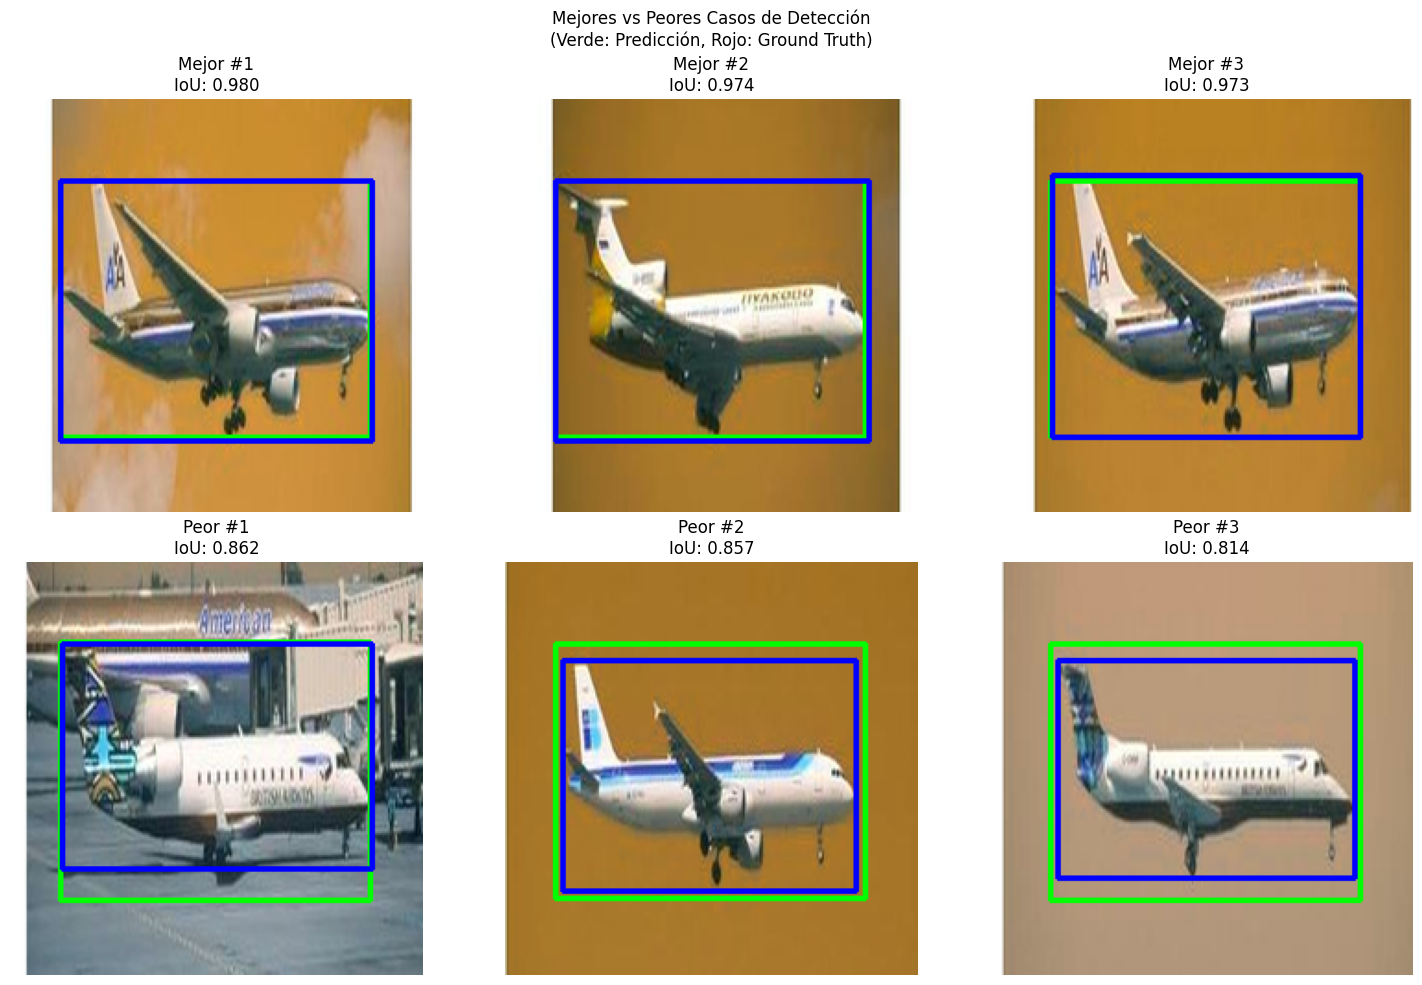

In [40]:
visualize_extreme_cases(batch_results, top_n=3)

In [58]:
print(f"Total de imágenes en tu test set: {len(x_test)}")
print(f"Actualmente evaluando: 60 imágenes")
print(f"Porcentaje del dataset: {60/len(x_test)*100:.1f}%")

Total de imágenes en tu test set: 160
Actualmente evaluando: 60 imágenes
Porcentaje del dataset: 37.5%


In [42]:
def evaluate_batch(images, labels, model, image_size, batch_size=8):
    """Evaluación por lotes para mayor eficiencia"""
    results = []

    for i in tqdm(range(0, len(images), batch_size), desc=f"Procesando lotes de {batch_size}"):
        batch_end = min(i + batch_size, len(images))
        batch_images = images[i:batch_end]
        batch_labels = labels[i:batch_end]

        # Preprocesar lote
        batch_processed = []
        original_shapes = []

        for img in batch_images:
            original_shapes.append(img.shape[:2])  # (height, width)
            img_resized = cv2.resize(img, (image_size, image_size), interpolation=cv2.INTER_AREA)
            img_normalized = img_resized / 255.0
            batch_processed.append(img_normalized)

        batch_array = np.array(batch_processed)

        # Predicción del lote completo
        predictions = model.predict(batch_array, verbose=0)

        # Procesar resultados del lote
        for j, (pred, label, original_shape, original_img) in enumerate(zip(predictions, batch_labels, original_shapes, batch_images)):
            h, w = original_shape

            # Bounding boxes
            box_predicted = [
                int(pred[0] * w), int(pred[1] * h),
                int(pred[2] * w), int(pred[3] * h)
            ]

            box_truth = [
                int(label[0] * w), int(label[1] * h),
                int(label[2] * w), int(label[3] * h)
            ]

            # Métricas
            iou = calculate_iou(box_predicted, box_truth)
            precision, recall = calculate_precision_recall(box_predicted, box_truth, iou_threshold=0.5)

            results.append({
                'index': i + j,
                'image': original_img,
                'box_predicted': box_predicted,
                'box_truth': box_truth,
                'iou': iou,
                'precision': precision,
                'recall': recall
            })

    return results

# Usar evaluación por lotes
logger.info("Iniciando evaluación por lotes...")
batch_results = evaluate_batch(x_test[:160], y_test[:160], model, 224, batch_size=8)

# Calcular métricas
if batch_results:
    total_iou = sum([r['iou'] for r in batch_results])
    total_precision = sum([r['precision'] for r in batch_results])
    total_recall = sum([r['recall'] for r in batch_results])

    mean_iou = total_iou / len(batch_results)
    mean_precision = total_precision / len(batch_results)
    mean_recall = total_recall / len(batch_results)
    f1_score = 2 * (mean_precision * mean_recall) / (mean_precision + mean_recall) if (mean_precision + mean_recall) > 0 else 0

    print(f"\n=== MÉTRICAS FINALES (EVALUACIÓN POR LOTES) ===")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"Mean Precision: {mean_precision:.4f}")
    print(f"Mean Recall: {mean_recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")
    print(f"Imágenes procesadas: {len(batch_results)}")

Procesando lotes de 8: 100%|██████████| 20/20 [00:04<00:00,  4.72it/s]


=== MÉTRICAS FINALES (EVALUACIÓN POR LOTES) ===
Mean IoU: 0.9221
Mean Precision: 1.0000
Mean Recall: 1.0000
F1 Score: 1.0000
Imágenes procesadas: 160


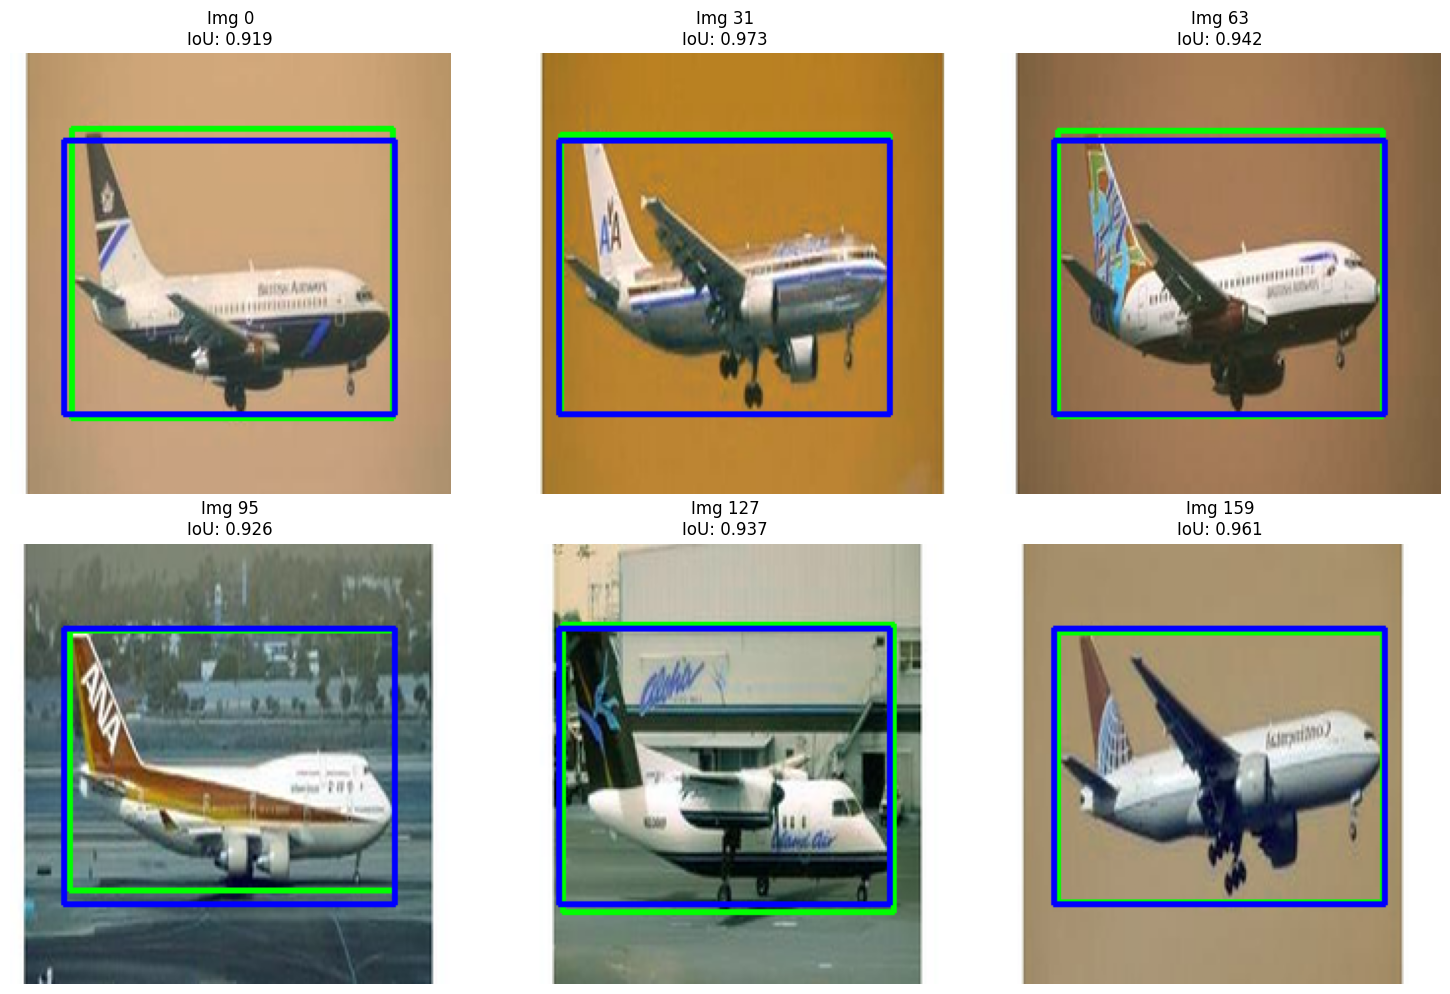

In [43]:
import matplotlib.pyplot as plt

def visualize_results(results, num_samples=6):
    """Visualiza resultados de la evaluación"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    # Seleccionar muestras para visualizar
    sample_indices = np.linspace(0, len(results)-1, num_samples, dtype=int)

    for i, idx in enumerate(sample_indices):
        if i >= len(axes):
            break

        result = results[idx]
        img = result['image'].copy()

        # Dibujar bounding boxes
        # Verdadero (verde)
        cv2.rectangle(img,
                     (result['box_truth'][0], result['box_truth'][1]),
                     (result['box_truth'][2], result['box_truth'][3]),
                     (0, 255, 0), 2)

        # Predicho (rojo)
        cv2.rectangle(img,
                     (result['box_predicted'][0], result['box_predicted'][1]),
                     (result['box_predicted'][2], result['box_predicted'][3]),
                     (255, 0, 0), 2)

        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Img {result['index']}\nIoU: {result['iou']:.3f}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Visualizar resultados (usar batch_results o evaluation_results)
if 'batch_results' in locals() and batch_results:
    visualize_results(batch_results, num_samples=6)
elif 'evaluation_results' in locals() and evaluation_results:
    visualize_results(evaluation_results, num_samples=6)

In [44]:
# Calcular métricas generales
if batch_results:
    total_iou = sum([r['iou'] for r in batch_results])
    total_precision = sum([r['precision'] for r in batch_results])
    total_recall = sum([r['recall'] for r in batch_results])

    mean_iou = total_iou / len(batch_results)
    mean_precision = total_precision / len(batch_results)
    mean_recall = total_recall / len(batch_results)
    f1_score = 2 * (mean_precision * mean_recall) / (mean_precision + mean_recall) if (mean_precision + mean_recall) > 0 else 0

    # Calcular F1 Score para cada resultado individual
    for result in batch_results:
        prec = result['precision']
        rec = result['recall']
        result['f1_score'] = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

    # Encontrar mejores y peores casos
    # Ordenar por IoU
    sorted_by_iou = sorted(batch_results, key=lambda x: x['iou'], reverse=True)
    best_iou = sorted_by_iou[0]
    worst_iou = sorted_by_iou[-1]

    # Ordenar por F1 Score
    sorted_by_f1 = sorted(batch_results, key=lambda x: x['f1_score'], reverse=True)
    best_f1 = sorted_by_f1[0]
    worst_f1 = sorted_by_f1[-1]

    # Ordenar por Precision
    sorted_by_precision = sorted(batch_results, key=lambda x: x['precision'], reverse=True)
    best_precision = sorted_by_precision[0]
    worst_precision = sorted_by_precision[-1]

    # Mostrar resultados
    print(f"\n=== MÉTRICAS FINALES (EVALUACIÓN POR LOTES) ===")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"Mean Precision: {mean_precision:.4f}")
    print(f"Mean Recall: {mean_recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")
    print(f"Imágenes procesadas: {len(batch_results)}")

    print(f"\n=== ANÁLISIS DE MEJORES Y PEORES CASOS ===")

    # Mejores casos
    print(f"\n🎯 MEJORES CASOS:")
    print(f"Mejor IoU: {best_iou['iou']:.4f} (Imagen #{best_iou['index']})")
    print(f"  - Precision: {best_iou['precision']:.4f}, Recall: {best_iou['recall']:.4f}, F1: {best_iou['f1_score']:.4f}")

    print(f"Mejor F1 Score: {best_f1['f1_score']:.4f} (Imagen #{best_f1['index']})")
    print(f"  - IoU: {best_f1['iou']:.4f}, Precision: {best_f1['precision']:.4f}, Recall: {best_f1['recall']:.4f}")

    print(f"Mejor Precision: {best_precision['precision']:.4f} (Imagen #{best_precision['index']})")
    print(f"  - IoU: {best_precision['iou']:.4f}, Recall: {best_precision['recall']:.4f}, F1: {best_precision['f1_score']:.4f}")

    # Peores casos
    print(f"\n❌ PEORES CASOS:")
    print(f"Peor IoU: {worst_iou['iou']:.4f} (Imagen #{worst_iou['index']})")
    print(f"  - Precision: {worst_iou['precision']:.4f}, Recall: {worst_iou['recall']:.4f}, F1: {worst_iou['f1_score']:.4f}")

    print(f"Peor F1 Score: {worst_f1['f1_score']:.4f} (Imagen #{worst_f1['index']})")
    print(f"  - IoU: {worst_f1['iou']:.4f}, Precision: {worst_f1['precision']:.4f}, Recall: {worst_f1['recall']:.4f}")

    print(f"Peor Precision: {worst_precision['precision']:.4f} (Imagen #{worst_precision['index']})")
    print(f"  - IoU: {worst_precision['iou']:.4f}, Recall: {worst_precision['recall']:.4f}, F1: {worst_precision['f1_score']:.4f}")

    # Estadísticas adicionales
    print(f"\n📊 ESTADÍSTICAS DETALLADAS:")
    iou_values = [r['iou'] for r in batch_results]
    precision_values = [r['precision'] for r in batch_results]
    recall_values = [r['recall'] for r in batch_results]
    f1_values = [r['f1_score'] for r in batch_results]

    print(f"IoU - Min: {min(iou_values):.4f}, Max: {max(iou_values):.4f}, Std: {np.std(iou_values):.4f}")
    print(f"Precision - Min: {min(precision_values):.4f}, Max: {max(precision_values):.4f}, Std: {np.std(precision_values):.4f}")
    print(f"Recall - Min: {min(recall_values):.4f}, Max: {max(recall_values):.4f}, Std: {np.std(recall_values):.4f}")
    print(f"F1 Score - Min: {min(f1_values):.4f}, Max: {max(f1_values):.4f}, Std: {np.std(f1_values):.4f}")

    # Contar casos por rangos de rendimiento
    excellent_iou = len([x for x in iou_values if x >= 0.8])
    good_iou = len([x for x in iou_values if 0.5 <= x < 0.8])
    poor_iou = len([x for x in iou_values if x < 0.5])

    print(f"\n📈 DISTRIBUCIÓN DE RENDIMIENTO (IoU):")
    print(f"Excelente (≥0.8): {excellent_iou} imágenes ({excellent_iou/len(batch_results)*100:.1f}%)")
    print(f"Bueno (0.5-0.8): {good_iou} imágenes ({good_iou/len(batch_results)*100:.1f}%)")
    print(f"Pobre (<0.5): {poor_iou} imágenes ({poor_iou/len(batch_results)*100:.1f}%)")


=== MÉTRICAS FINALES (EVALUACIÓN POR LOTES) ===
Mean IoU: 0.9221
Mean Precision: 1.0000
Mean Recall: 1.0000
F1 Score: 1.0000
Imágenes procesadas: 160

=== ANÁLISIS DE MEJORES Y PEORES CASOS ===

🎯 MEJORES CASOS:
Mejor IoU: 0.9928 (Imagen #58)
  - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
Mejor F1 Score: 1.0000 (Imagen #0)
  - IoU: 0.9189, Precision: 1.0000, Recall: 1.0000
Mejor Precision: 1.0000 (Imagen #0)
  - IoU: 0.9189, Recall: 1.0000, F1: 1.0000

❌ PEORES CASOS:
Peor IoU: 0.5814 (Imagen #133)
  - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
Peor F1 Score: 1.0000 (Imagen #159)
  - IoU: 0.9611, Precision: 1.0000, Recall: 1.0000
Peor Precision: 1.0000 (Imagen #159)
  - IoU: 0.9611, Recall: 1.0000, F1: 1.0000

📊 ESTADÍSTICAS DETALLADAS:
IoU - Min: 0.5814, Max: 0.9928, Std: 0.0548
Precision - Min: 1.0000, Max: 1.0000, Std: 0.0000
Recall - Min: 1.0000, Max: 1.0000, Std: 0.0000
F1 Score - Min: 1.0000, Max: 1.0000, Std: 0.0000

📈 DISTRIBUCIÓN DE RENDIMIENTO (IoU):
Excelente (≥0.8): 

In [49]:
def visualize_extreme_cases(batch_results, top_n=3):
    """Visualizar los mejores y peores casos"""
    import matplotlib.pyplot as plt

    # Ordenar por IoU
    sorted_results = sorted(batch_results, key=lambda x: x['iou'], reverse=True)

    # Mejores casos
    best_cases = sorted_results[:top_n]
    worst_cases = sorted_results[-top_n:]

    fig, axes = plt.subplots(2, top_n, figsize=(15, 10))

    # Visualizar mejores casos
    for i, result in enumerate(best_cases):
        img = result['image'].copy()

        # Dibujar bounding boxes
        cv2.rectangle(img,
                     (result['box_predicted'][0], result['box_predicted'][1]),
                     (result['box_predicted'][2], result['box_predicted'][3]),
                     (0, 255, 0), 2)  # Verde para predicción

        cv2.rectangle(img,
                     (result['box_truth'][0], result['box_truth'][1]),
                     (result['box_truth'][2], result['box_truth'][3]),
                     (255, 0, 0), 2)  # Rojo para ground truth

        axes[0, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0, i].set_title(f'Mejor #{i+1}\nIoU: {result["iou"]:.3f}')
        axes[0, i].axis('off')

    # Visualizar peores casos
    for i, result in enumerate(worst_cases):
        img = result['image'].copy()

        # Dibujar bounding boxes
        cv2.rectangle(img,
                     (result['box_predicted'][0], result['box_predicted'][1]),
                     (result['box_predicted'][2], result['box_predicted'][3]),
                     (0, 255, 0), 2)  # Verde para predicción

        cv2.rectangle(img,
                     (result['box_truth'][0], result['box_truth'][1]),
                     (result['box_truth'][2], result['box_truth'][3]),
                     (255, 0, 0), 2)  # Rojo para ground truth

        axes[1, len(worst_cases) - 1 - i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[1, len(worst_cases) - 1 - i].set_title(f'Peor #{len(worst_cases) - i}\nIoU: {result["iou"]:.3f}')
        axes[1, len(worst_cases) - 1 - i].axis('off')

    plt.suptitle('Mejores vs Peores Casos de Detección\n(Verde: Predicción, Rojo: Ground Truth)')
    plt.tight_layout()
    plt.show()

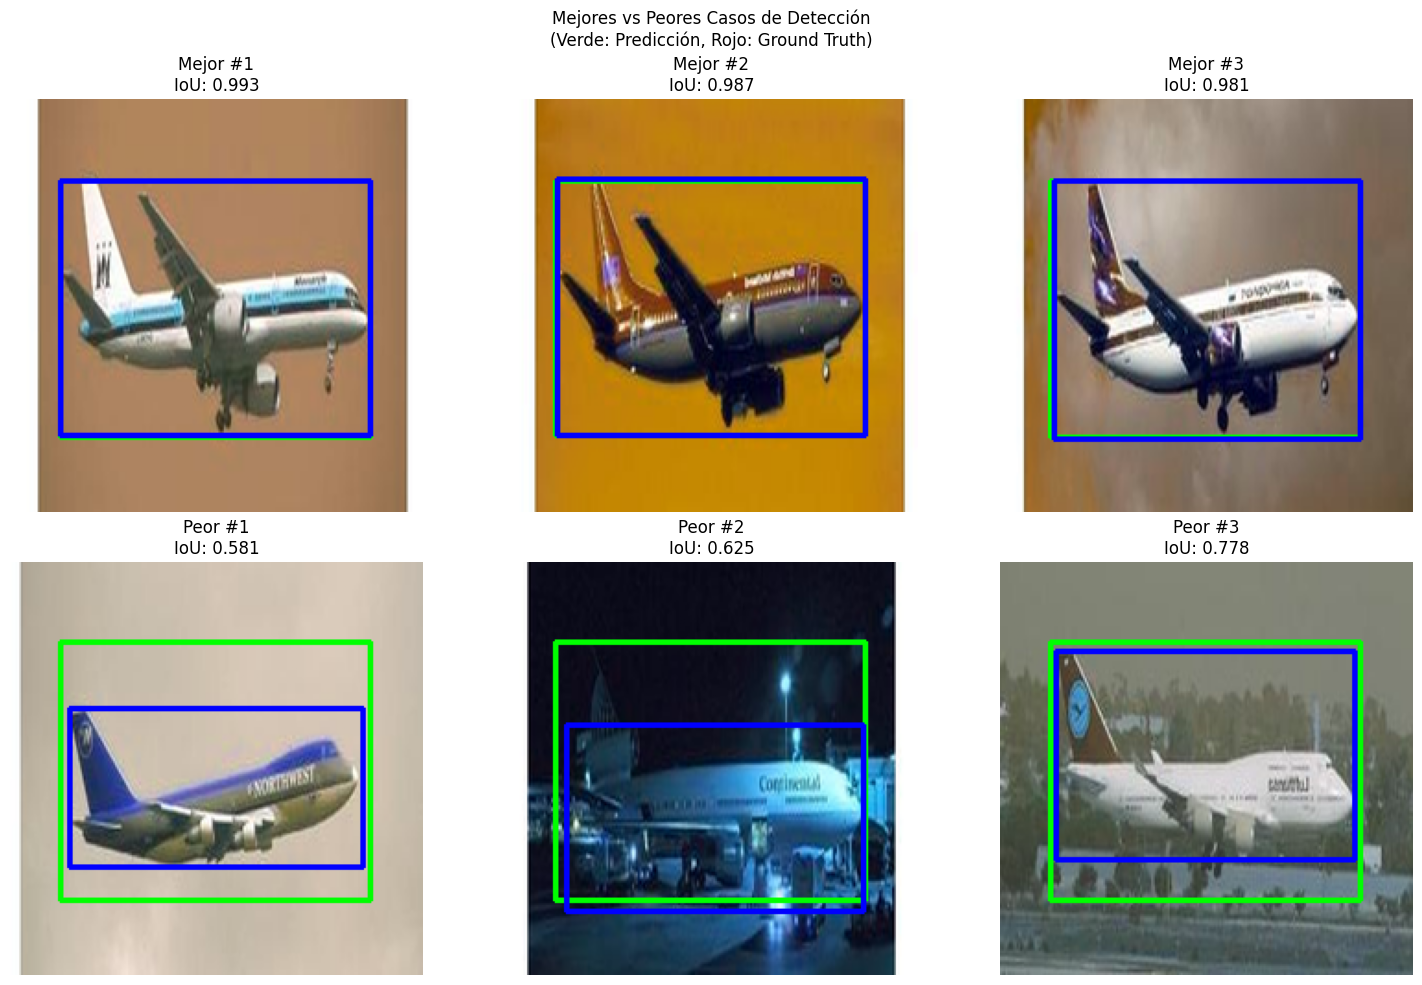

In [50]:
visualize_extreme_cases(batch_results, top_n=3)